<a href="https://colab.research.google.com/github/jainilpatel-gif/fake_news-detection/blob/main/fake_news_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fake vs Real News - EDA
Only Python, pandas, NumPy, Matplotlib. Upload `True.csv` and `Fake.csv` to the Colab session first (folder icon on the left).

In [2]:

import re
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TRUE_PATH = "True.csv"
FAKE_PATH = "Fake.csv"

In [3]:
# ---------- 1. Load & combine ----------
true_df = pd.read_csv(TRUE_PATH)
fake_df = pd.read_csv(FAKE_PATH)
true_df["label"] = "Real"
fake_df["label"] = "Fake"
df = pd.concat([true_df, fake_df], ignore_index=True)

In [4]:
# ---------- 2. Clean ----------
print("Shape:", df.shape)
print("Duplicates:", df.duplicated(subset=["title", "text"]).sum())
df = df.drop_duplicates(subset=["title", "text"]).reset_index(drop=True)
df["date"] = pd.to_datetime(df["date"].str.strip(), format="mixed", errors="coerce")   # a few Fake rows hold junk, not dates
print("Unparseable dates:", df["date"].isna().sum())
df["word_count"] = df["text"].fillna("").str.split().str.len()
df = df[df["word_count"] > 0]    # drop empty-text rows

COLORS = {"Real": "#2a9d8f", "Fake": "#e76f51"}

Shape: (44898, 5)
Duplicates: 5793
Unparseable dates: 6


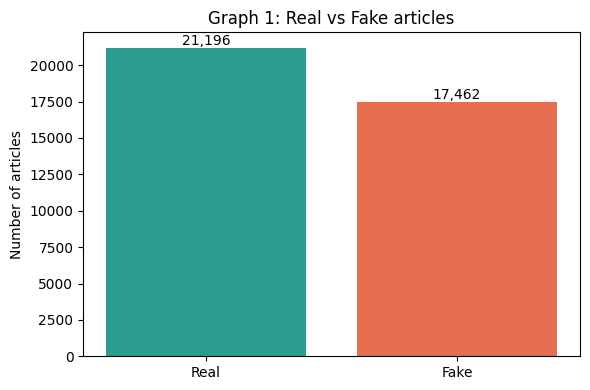

In [5]:
# ---------- Graph 1: class balance ----------
counts = df["label"].value_counts()
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(counts.index, counts.values, color=[COLORS[l] for l in counts.index])
for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
ax.set_title("Graph 1: Real vs Fake articles"); ax.set_ylabel("Number of articles")
plt.tight_layout(); plt.savefig("g1_class_balance.png", dpi=150); plt.show()

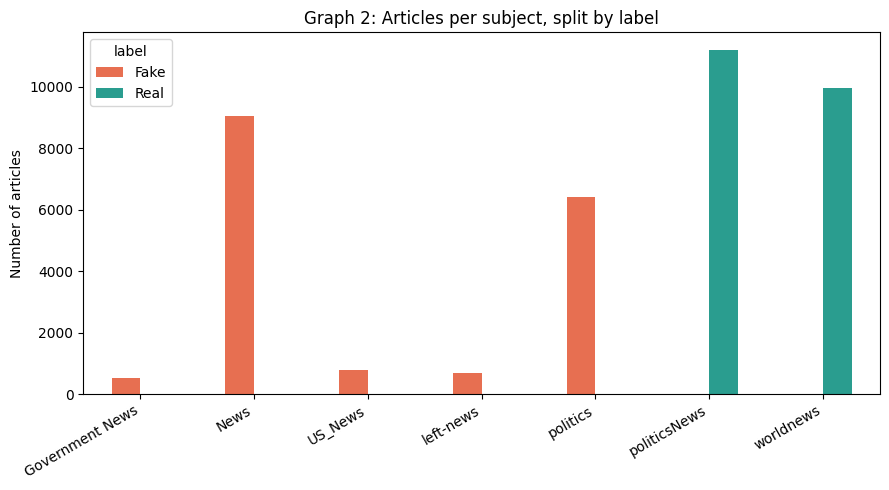

In [6]:
# ---------- Graph 2: subject by class ----------
sub = df.groupby(["subject", "label"]).size().unstack(fill_value=0)
ax = sub.plot(kind="bar", figsize=(9, 5), color=[COLORS[c] for c in sub.columns])
ax.set_title("Graph 2: Articles per subject, split by label")
ax.set_ylabel("Number of articles"); ax.set_xlabel("")
plt.xticks(rotation=30, ha="right")
plt.tight_layout(); plt.savefig("g2_subject_by_label.png", dpi=150); plt.show()

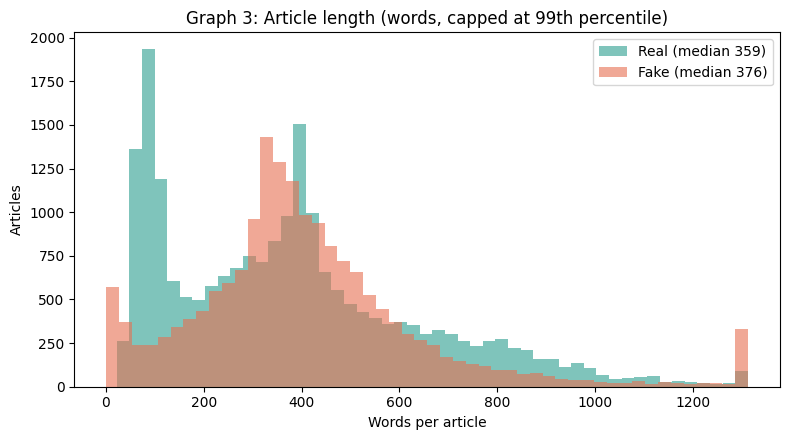

In [7]:
# ---------- Graph 3: article length ----------
cap = int(df["word_count"].quantile(0.99))
fig, ax = plt.subplots(figsize=(8, 4.5))
for lab in ["Real", "Fake"]:
    ax.hist(df.loc[df.label == lab, "word_count"].clip(upper=cap), bins=50,
            alpha=0.6, label=f"{lab} (median {int(df.loc[df.label == lab, 'word_count'].median())})",
            color=COLORS[lab])
ax.set_title("Graph 3: Article length (words, capped at 99th percentile)")
ax.set_xlabel("Words per article"); ax.set_ylabel("Articles"); ax.legend()
plt.tight_layout(); plt.savefig("g3_length_hist.png", dpi=150); plt.show()

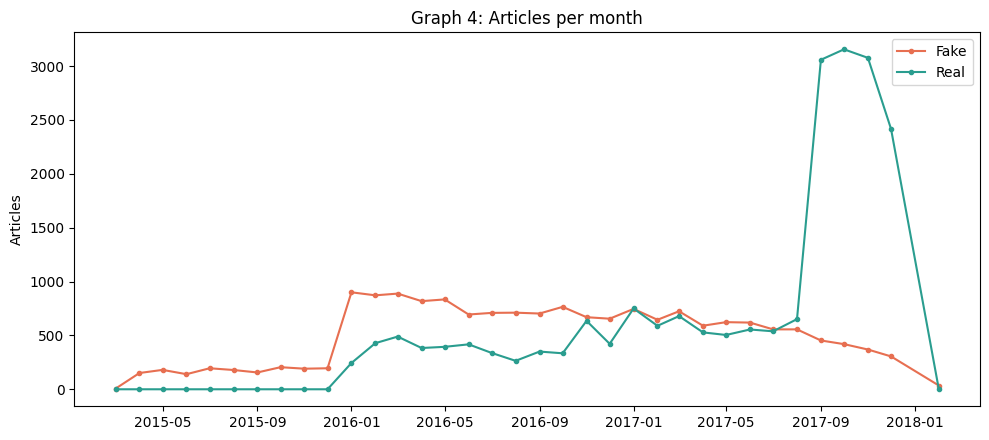

In [8]:
# ---------- Graph 4: articles over time ----------
ts = df.dropna(subset=["date"]).copy()
ts["month"] = ts["date"].dt.to_period("M").dt.to_timestamp()
monthly = ts.groupby(["month", "label"]).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(10, 4.5))
for lab in monthly.columns:
    ax.plot(monthly.index, monthly[lab], marker="o", ms=3, label=lab, color=COLORS[lab])
ax.set_title("Graph 4: Articles per month"); ax.set_ylabel("Articles"); ax.legend()
plt.tight_layout(); plt.savefig("g4_monthly_trend.png", dpi=150); plt.show()

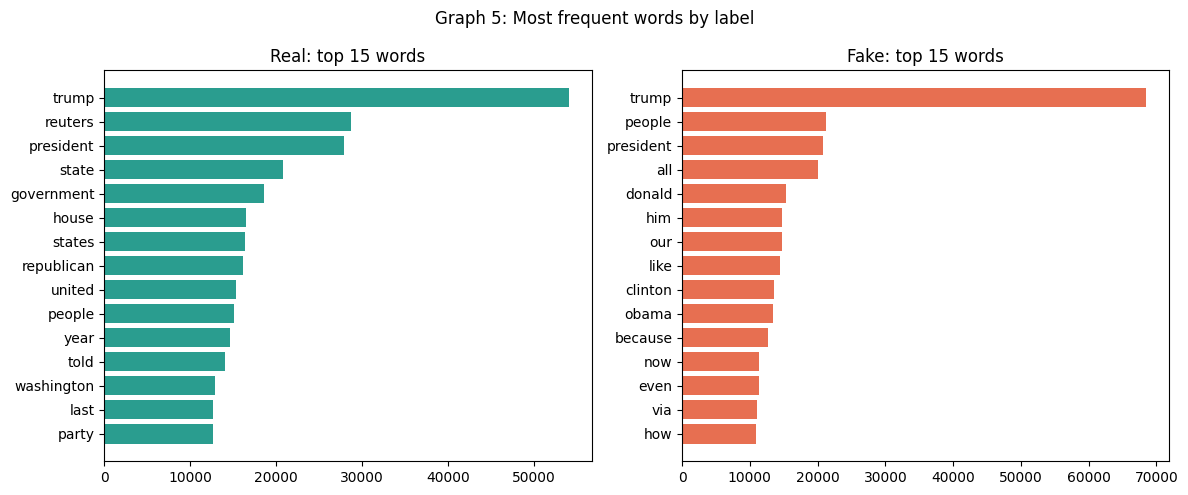

In [9]:
# ---------- Graph 5: top words ----------
STOP = set("""the a an and or but if in on at to of for with as by from that this these those is are was were
be been being it its he she they them his her their we you i not no so than then there which who whom what
when where will would can could should has have had do does did said says say also about after before over
under into out up down more most other some such only own same too very just one two new us mr mrs""".split())

def top_words(series, n=15):
    c = Counter()
    for t in series:
        c.update(w for w in re.findall(r"[a-z']+", t.lower()) if w not in STOP and len(w) > 2)
    return pd.Series(dict(c.most_common(n)))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, lab in zip(axes, ["Real", "Fake"]):
    tw = top_words(df.loc[df.label == lab, "text"]).sort_values()
    ax.barh(tw.index, tw.values, color=COLORS[lab]); ax.set_title(f"{lab}: top 15 words")
fig.suptitle("Graph 5: Most frequent words by label")
plt.tight_layout(); plt.savefig("g5_top_words.png", dpi=150); plt.show()

In [10]:
# ---------- Extra finding: source-tag leakage check ----------
reuters = df["text"].str[:120].str.contains("Reuters", case=False)
print("\nShare of articles with 'Reuters' in the first 120 chars:")
print(reuters.groupby(df["label"]).mean().round(3))
print("\nMedian words:", df.groupby("label")["word_count"].median().to_dict())
print("Subjects:\n", sub)


Share of articles with 'Reuters' in the first 120 chars:
label
Fake    0.001
Real    0.988
Name: text, dtype: float64

Median words: {'Fake': 376.0, 'Real': 359.0}
Subjects:
 label            Fake   Real
subject                     
Government News   515      0
News             9050      0
US_News           783      0
left-news         684      0
politics         6430      0
politicsNews        0  11216
worldnews           0   9980
